# Assignment 06 - Knock Airport Weather

## Author: Tihana Gray

### Section 1 - Importing and reading the file

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

csv_path = r"C:\Users\tihan\OneDrive\Desktop\ATU\programming-for-data-analytics\assignments\climate_data.csv"

# Read the CSV file with error handling
with open(csv_path, "r", encoding="utf-8", errors="replace") as f:
    # Read all lines from the file
    lines = f.readlines()

- Created a variable called `csv_path`, which stores the location of my CSV file.
- Using a raw string (`r"..."`) means Python reads the backslashes in the Windows file path correctly.<br>
This part of the code sets up everything I need before reading or analysing any data.<br>

- Before loading the CSV with pandas, I opened the file using Python’s built-in `open()` function.
- This part checks that the file can be opened without errors.

Some of the climate data files contain special characters or metadata at the top, so I use:
- `encoding="utf-8"` ensures special characters read correctly
- `errors="replace"` avoids the program crashing if there is unusual text in the file
- `readlines()` loads all lines into memory so I can inspect the file if needed.

📚 References:
- https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html
- https://stackoverflow.com/questions/904041/reading-a-utf8-csv-file-with-python
- https://www.w3schools.com/python/ref_file_readlines.asp
- https://www.geeksforgeeks.org/python/readline-in-python/
- https://docs.python.org/3/library/codecs.html#codecs.open

### Section 2 - Loading and reading the data

In [20]:
column_names = [  # Manually defining column names because the CSV file has no header line
    "date", "ind", "rain", "ind2", "temp", "ind3",
    "wetb", "dewpt", "vappr", "rhum",
    "msl", "ind4", "wdsp", "ind5", "wddir", "ww",
    "w", "sun", "vis", "clht", "clamt"
]  # These names match the metadata entries in the file

df = pd.read_csv(csv_path, skiprows=25, header=None, names=column_names)  
# skiprows=25 skips metadata lines; header=None tells pandas no header exists. names=column_names supplies column names. 
# https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html



C:\Users\tihan\AppData\Local\Temp\ipykernel_25744\2734109144.py:8: DtypeWarning: Columns (2,10,12,14,15,16,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, skiprows=25, header=None, names=column_names)


The climate CSV file includes 25 lines of metadata followed by rows of actual data.<br>
There is no row containing column names, so pandas cannot detect the structure automatically.
- Created a list called `column_names` to define the correct headers manually.
- Used `skiprows=25` so pandas will ignore the metadata.
- Used `header=None` to prevent pandas from using the first data row as a header.
- Used `names=column_names` so pandas assigns the correct headers to each column.

Now the dataset loads cleanly into a DataFrame.

📚 References:
- https://stackoverflow.com/questions/29287224/pandas-read-in-table-without-headers
- https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html
- https://stackoverflow.com/questions/24962908/how-can-i-read-only-the-header-column-of-a-csv-file-using-python
- https://www.geeksforgeeks.org/pandas/python-read-csv-using-pandas-read_csv/

In [21]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True)  
# Converting the date column to proper datetime objects 
# https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html

df = df.set_index("date")  
# Setting the datetime column as the index for time-series operations 
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.set_index.html

df = df.sort_index()  
# Sorting the index so data is in chronological order 
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_index.html

ts = df[["temp"]].rename(columns={"temp": "temperature"})  
# Selecting only the temperature column and renaming it for clarity 
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rename.html


C:\Users\tihan\AppData\Local\Temp\ipykernel_25744\424075686.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"], dayfirst=True)


This step turns the dataset into time series, which is needed for resampling and plotting.
- I converted the `"date"` column into a datetime format using `pd.to_datetime()` because the raw data is a string.
- Then I set that column as the index.
- Sorting guarantees chronological order.
- I extracted just the temperature column and renamed it for clarity.

📚 References:
- https://www.geeksforgeeks.org/python/python-pandas-to_datetime/
- https://stackoverflow.com/questions/68576507/how-to-display-day-first-with-pd-to-datetime
- https://www.geeksforgeeks.org/python/python-pandas-to_datetime/
- https://pandas.pydata.org/pandas-docs/version/0.20/generated/pandas.to_datetime.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.set_index.html
- https://stackoverflow.com/questions/37610983/how-set-column-as-date-index
- https://www.geeksforgeeks.org/pandas/python-pandas-dataframe-set_index/

### Section 3: Temperature plot

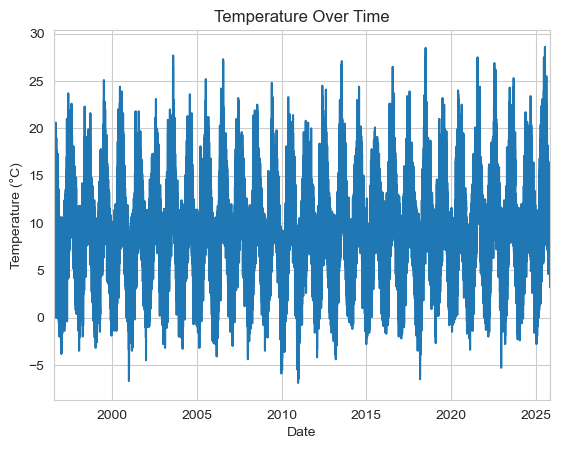

In [22]:
sns.set_style("whitegrid")  # Applying a clean seaborn style to all plots
# https://seaborn.pydata.org/generated/seaborn.set_style.html

ts["temperature"].plot()  # Drawing a line plot of temperature over time
# https://pandas.pydata.org/docs/reference/api/pandas.Series.plot.html

plt.title("Temperature Over Time")  # Title explaining the plot
plt.xlabel("Date")  # Labels the x-axis
plt.ylabel("Temperature (°C)")  # Labels the y-axis

plt.show()  # Shows the plot
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html

This is the first temperature plot. <br>
I apply seaborn `"whitegrid"` style to help make the plot clearer and more visually appealing.

The line plot is created with `ts["temperature"].plot()`, which automatically uses the dates from the index as the x-axis.

The labels and title show what the graph represents.<br>
This plot shows the raw temperature readings exactly as they appear in the dataset.

📚 References:
- https://seaborn.pydata.org/generated/seaborn.set_style.html
- https://pandas.pydata.org/docs/reference/api/pandas.Series.plot.html
- https://seaborn.pydata.org/tutorial/aesthetics.html
- https://www.w3schools.com/python/matplotlib_labels.asp
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html

### Section 4: Daily mean temperature

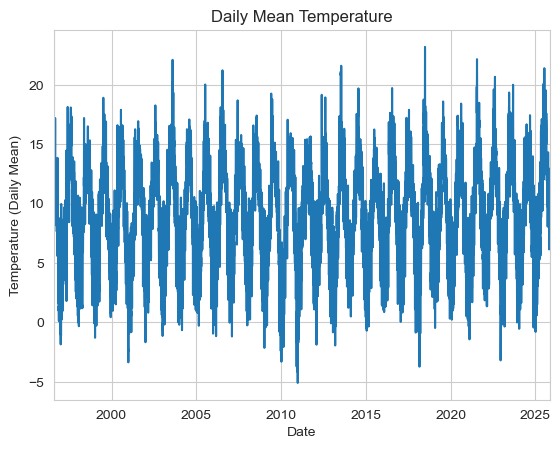

In [23]:
daily_mean = ts.resample("D").mean()  
# Calculating the average temperature for each day
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html

sns.set_style("whitegrid")  # Applying seaborn styling again

daily_mean["temperature"].plot()  # Plotting the daily mean temperature
plt.title("Daily Mean Temperature")  # Title
plt.xlabel("Date")  # Labels the x-axis
plt.ylabel("Temperature (Daily Mean)")  # Labels the y-axis

plt.show()  # Showing plot


This graph shows the mean temperature per day.<br>
The `.resample("D")` function groups data by day, and `.mean()` calculates the average for each group.

This smooths out the raw readings and reveals clearer daily patterns.

I used the same simple plotting format to keep everything consistent.

📚 References:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html
- https://stackoverflow.com/questions/49019245/resample-pandas-with-minimum-required-number-of-observations
- https://pandas.pydata.org/pandas-docs/version/1.2/reference/api/pandas.DataFrame.resample.html

### Section 5: Monthly mean temperature

C:\Users\tihan\AppData\Local\Temp\ipykernel_25744\1809969644.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mean = ts.resample("M").mean()


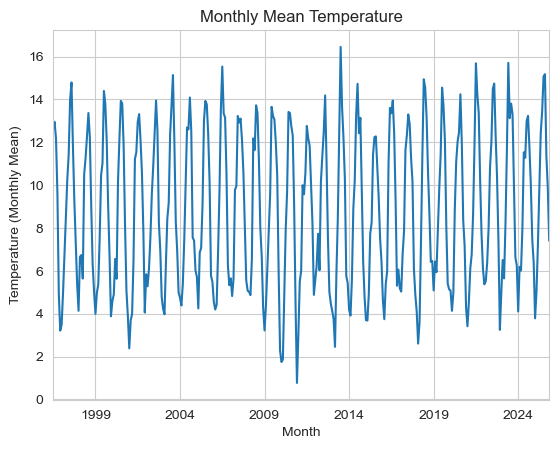

In [24]:
monthly_mean = ts.resample("M").mean()  
# Calculating the average temperature for each month

sns.set_style("whitegrid")  # Applying seaborn style

monthly_mean["temperature"].plot()  # Plotting monthly mean temperature
plt.title("Monthly Mean Temperature")  # Title
plt.xlabel("Month")  # Labels the x-axis
plt.ylabel("Temperature (Monthly Mean)")  # Labels the y-axis

plt.show()  # Showing plot


This graph shows monthly mean temperature.<br>
The "M" frequency in .resample("M") groups the data by each calendar month.

📚 References:
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html
- www.geeksforgeeks.org/python/python-pandas-dataframe-resample/